In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# MNIST 데이터 로드
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 데이터 전처리
x_train = x_train / 255.0
x_test = x_test / 255.0

# 채널 차원 추가 (CNN 입력용)
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

# 정상(0~8)과 이상치(9) 구분
normal_classes = list(range(9))  # 0~8 정상
anomaly_classes = [9]           # 9 이상치

# 학습 데이터: 정상만 사용
x_train_normal = x_train[np.isin(y_train, normal_classes)]
y_train_normal = np.zeros(len(x_train_normal))  # 정상 = 0

# 테스트 데이터: 정상/이상치 모두
y_test_labels = np.where(np.isin(y_test, normal_classes), 0, 1)  # 0=정상, 1=이상

model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')  # 이진 분류
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(
    x_train_normal, y_train_normal,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

# 테스트 정확도
test_loss, test_acc = model.evaluate(x_test, y_test_labels)
print(f'Test Accuracy: {test_acc:.4f}')

# 몇 개 예측 확인
preds = model.predict(x_test[:10])
for i, p in enumerate(preds):
    print(f'Label: {y_test_labels[i]}, Predicted anomaly prob: {p[0]:.2f}')


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 784)                 │         101,136 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0466 - val_loss: 0.0230
Epoch 2/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0182 - val_loss: 0.0156
Epoch 3/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0136 - val_loss: 0.0126
Epoch 4/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0115 - val_loss: 0.0108
Epoch 5/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0100 - val_loss: 0.0097
Epoch 6/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0090 - val_loss: 0.0092
Epoch 7/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0083 - val_loss: 0.0083
Epoch 8/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0078 - val_loss: 0.0092
Epoch 9/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0073 - val_loss: 0.0080
Epoch 10/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0070 - val_loss: 0.0071
Epoch 11/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0066 - val_loss: 0.0070
Epoch 12/20
381/381 ━━━━━━━━━━━━━━━━━━━━ 

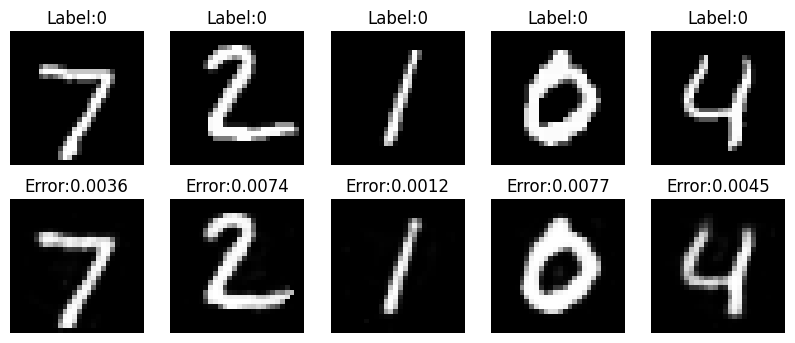

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
import matplotlib.pyplot as plt

# MNIST 데이터 로드
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 정규화
x_train = x_train / 255.0
x_test = x_test / 255.0

# 채널 없이 Flatten 형태 (Autoencoder용)
x_train_flat = x_train.reshape(-1, 28*28)
x_test_flat = x_test.reshape(-1, 28*28)

# 정상 클래스: 0~8
normal_classes = list(range(9))
x_train_normal = x_train_flat[np.isin(y_train, normal_classes)]

input_dim = 28*28
encoding_dim = 64  # 잠재 공간 차원

input_img = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(encoding_dim, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

history = autoencoder.fit(
    x_train_normal, x_train_normal,  # 입력 = 출력 (재구성)
    epochs=20,
    batch_size=128,
    validation_split=0.1
)

# 테스트 데이터
x_test_labels = np.where(np.isin(y_test, normal_classes), 0, 1)  # 0=정상, 1=이상

# 재구성
x_test_pred = autoencoder.predict(x_test_flat)

# MSE 계산
reconstruction_error = np.mean(np.square(x_test_flat - x_test_pred), axis=1)

# 임계값 설정 (예: 정상 데이터 MSE 평균 + 3*std)
threshold = np.mean(np.square(x_train_normal - autoencoder.predict(x_train_normal))) + \
            3*np.std(np.square(x_train_normal - autoencoder.predict(x_train_normal)))

# 이상치 판정
y_pred = (reconstruction_error > threshold).astype(int)

# 정확도 확인
accuracy = np.mean(y_pred == x_test_labels)
print(f"Test Accuracy: {accuracy:.4f}")

# 재구성 예시
n = 5
plt.figure(figsize=(10,4))
for i in range(n):
    # 원본
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Label:{x_test_labels[i]}")
    plt.axis('off')
    
    # 재구성
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(x_test_pred[i].reshape(28,28), cmap='gray')
    plt.title(f"Error:{reconstruction_error[i]:.4f}")
    plt.axis('off')
plt.show()
